In [59]:
# ------------------------------------------------------------------
# EVALUATION NOTEBOOK
# 
# Bu notebook'ta:
# 1) Recommendation modelleri için evaluation setup kuracağız
# 2) Train-test ayrımı yapacağız
# 3) Ranking metriklerini hesaplayacağız
# 4) Farklı modelleri karşılaştıracağız
#
# Bu aşamada özellikle şu modellere zemin hazırlıyoruz:
# - Popularity baseline
# - Content-based filtering
# - Collaborative filtering
# - Hybrid recommendation
# ------------------------------------------------------------------

In [60]:
# ------------------------------------------------------------------
# GEREKLİ KÜTÜPHANELER
# ------------------------------------------------------------------

import pandas as pd
import numpy as np

In [61]:
# ------------------------------------------------------------------
# CF VERİSİNİ YÜKLEME
#
# Evaluation için user-item interaction verisini kullanacağız.
# Burada reviews_cf_last.csv dosyasını yüklüyoruz.
# Bu dosyada her kullanıcı-ürün çifti için tek bir rating var.
# ------------------------------------------------------------------

cf_data = pd.read_csv("../data_interim/reviews_cf_last.csv")

print("cf_data shape:", cf_data.shape)
cf_data.head()

cf_data shape: (1088891, 4)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_31538/622460587.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cf_data = pd.read_csv("../data_interim/reviews_cf_last.csv")


,author_id,product_id,rating,submission_time
0,538863,P420652,1,2018-11-01
1,549704,P218700,5,2011-04-21
2,557770,P232903,5,2016-02-19
3,561736,P421998,5,2018-07-28
4,561736,P445951,5,2018-07-28


In [62]:
# ------------------------------------------------------------------
# KOLON KONTROLÜ
# ------------------------------------------------------------------

print(cf_data.columns.tolist())

['author_id', 'product_id', 'rating', 'submission_time']


In [63]:
# ------------------------------------------------------------------
# VERİ TİPLERİNİ DÜZELTME
#
# author_id ve product_id kolonlarını string'e çeviriyoruz.
# Böylece karışık tip kaynaklı sorunları engellemiş oluyoruz.
# submission_time kolonunu da datetime formatına çeviriyoruz.
# ------------------------------------------------------------------

cf_data["author_id"] = cf_data["author_id"].astype(str)
cf_data["product_id"] = cf_data["product_id"].astype(str)
cf_data["submission_time"] = pd.to_datetime(cf_data["submission_time"], errors="coerce")

print(cf_data.dtypes)

author_id                  object
product_id                 object
rating                      int64
submission_time    datetime64[ns]
dtype: object


In [64]:
# ------------------------------------------------------------------
# KULLANICI ETKİLEŞİM SAYILARI
#
# Her kullanıcının kaç farklı rating verdiğini hesaplıyoruz.
# Evaluation için çok az etkileşimi olan kullanıcıları kullanmak istemiyoruz.
# ------------------------------------------------------------------

user_interaction_counts = (
    cf_data.groupby("author_id")["product_id"]
    .count()
    .sort_values(ascending=False)
)

print("Toplam kullanıcı sayısı:", user_interaction_counts.shape[0])
print(user_interaction_counts.head(10))

Toplam kullanıcı sayısı: 503216
author_id
1696370280     292
1288462295     204
7375781965     154
1930716686     153
2330399812     151
5060164185     150
1492711942     135
1738022745     135
10690040573    131
12640060683    118
Name: product_id, dtype: int64


In [65]:
# ------------------------------------------------------------------
# EVALUATION İÇİN UYGUN KULLANICILARI SEÇME
#
# En az 5 etkileşimi olan kullanıcıları seçiyoruz.
# Bu eşik sayesinde train-test split daha anlamlı hale geliyor.
# ------------------------------------------------------------------

min_user_interactions = 5

eligible_users = user_interaction_counts[
    user_interaction_counts >= min_user_interactions
].index.tolist()

print("En az 5 etkileşimi olan kullanıcı sayısı:", len(eligible_users))

En az 5 etkileşimi olan kullanıcı sayısı: 40435


In [66]:
# ------------------------------------------------------------------
# SADECE UYGUN KULLANICILARI TUTMA
#
# Evaluation setup'ında sadece en az 5 etkileşimi olan kullanıcıları
# kullanacağız.
# ------------------------------------------------------------------

eval_df = cf_data[cf_data["author_id"].isin(eligible_users)].copy()

print("Evaluation dataframe shape:", eval_df.shape)
eval_df.head()

Evaluation dataframe shape: (370966, 4)


,author_id,product_id,rating,submission_time
5,562130,P380030,5,2016-05-09
6,562130,P381030,5,2014-11-29
7,582399,P420652,5,2018-11-21
8,582399,P421243,4,2019-02-10
12,681955,P482681,5,2022-04-17


In [67]:
# ------------------------------------------------------------------
# RELEVANT ITEM TANIMI
#
# rating >= 4 olan ürünleri "relevant" kabul ediyoruz.
# Yani kullanıcı bu ürünü beğenmiş / uygun bulmuş sayılıyor.
# ------------------------------------------------------------------

eval_df["is_relevant"] = (eval_df["rating"] >= 4).astype(int)

print(eval_df["is_relevant"].value_counts())

is_relevant
1    312975
0     57991
Name: count, dtype: int64


In [68]:
# ------------------------------------------------------------------
# KULLANICI BAŞINA RELEVANT ITEM SAYISI
#
# User-based holdout yapabilmek için kullanıcının en az 1 relevant item'ı
# olması gerekir. Hatta testte 1 ürün saklayacağımız için bu çok önemli.
# ------------------------------------------------------------------

relevant_counts = (
    eval_df.groupby("author_id")["is_relevant"]
    .sum()
    .sort_values(ascending=False)
)

print(relevant_counts.head(10))
print("En az 1 relevant item'ı olan kullanıcı sayısı:", (relevant_counts >= 1).sum())

author_id
1696370280     253
2330399812     151
1288462295     149
7375781965     149
5060164185     145
1492711942     133
10690040573    131
12640060683    118
1930716686     114
1314992825     114
Name: is_relevant, dtype: int64
En az 1 relevant item'ı olan kullanıcı sayısı: 40175


In [69]:
# ------------------------------------------------------------------
# USER-BASED HOLDOUT SPLIT
#
# Amaç:
# Her kullanıcı için 1 adet relevant item'ı test setine almak
# Geri kalan veriyi train seti olarak kullanmak
#
# Böylece:
# Model kullanıcının geçmişine bakarak bu saklanan ürünü tahmin edebiliyor mu?
# bunu test edebileceğiz
# ------------------------------------------------------------------

import numpy as np

train_rows = []
test_rows = []

# Kullanıcı bazında grupla
grouped = eval_df.groupby("author_id")

for user_id, group in grouped:

    # Kullanıcının relevant item'larını al
    relevant_items = group[group["is_relevant"] == 1]

    # Eğer hiç relevant item yoksa skip (zaten çok az olmalı)
    if len(relevant_items) == 0:
        continue

    # Test için 1 tane relevant item seç
    test_sample = relevant_items.sample(n=1, random_state=42)

    # Geri kalanlar train
    train_sample = group.drop(test_sample.index)

    test_rows.append(test_sample)
    train_rows.append(train_sample)

# DataFrame oluştur
train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (329236, 5)
Test shape: (40175, 5)


In [70]:
# ------------------------------------------------------------------
# SPLIT DOĞRULAMA
# ------------------------------------------------------------------

print("Train kullanıcı sayısı:", train_df["author_id"].nunique())
print("Test kullanıcı sayısı:", test_df["author_id"].nunique())

# Her kullanıcı testte sadece 1 item mı?
test_counts = test_df.groupby("author_id").size()

print("Testte max item sayısı:", test_counts.max())
print("Testte min item sayısı:", test_counts.min())

Train kullanıcı sayısı: 40175
Test kullanıcı sayısı: 40175
Testte max item sayısı: 1
Testte min item sayısı: 1


In [71]:
# ------------------------------------------------------------------
# TRAIN SET İLE CF MODELİNİ YENİDEN KURMA
#
# Evaluation adil olsun diye collaborative filtering modelini
# sadece train_df kullanarak kuruyoruz.
# Test setindeki ürünler model eğitiminde kullanılmayacak.
# ------------------------------------------------------------------

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

cf_train_data = train_df.copy()

# --------------------------------------------------------------
# 1) User / item mapping
# --------------------------------------------------------------
user_ids = cf_train_data["author_id"].unique()
item_ids = cf_train_data["product_id"].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_item = {idx: item_id for item_id, idx in item_to_idx.items()}

# --------------------------------------------------------------
# 2) Index kolonları
# --------------------------------------------------------------
cf_train_data["user_idx"] = cf_train_data["author_id"].map(user_to_idx)
cf_train_data["item_idx"] = cf_train_data["product_id"].map(item_to_idx)

# --------------------------------------------------------------
# 3) Sparse user-item matrix
# --------------------------------------------------------------
user_item_matrix = csr_matrix(
    (
        cf_train_data["rating"],
        (cf_train_data["user_idx"], cf_train_data["item_idx"])
    ),
    shape=(len(user_to_idx), len(item_to_idx))
)

print("Train user-item matrix shape:", user_item_matrix.shape)

# --------------------------------------------------------------
# 4) TruncatedSVD ile latent factor çıkarma
# --------------------------------------------------------------
n_factors = 50

svd = TruncatedSVD(n_components=n_factors, random_state=42)
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T

print("User latent matrix shape:", user_factors.shape)
print("Item latent matrix shape:", item_factors.shape)

# --------------------------------------------------------------
# 5) Tahmini skor matrisi
# --------------------------------------------------------------
predicted_scores = user_factors @ item_factors.T

print("Predicted score matrix shape:", predicted_scores.shape)

Train user-item matrix shape: (40175, 2242)
User latent matrix shape: (40175, 50)
Item latent matrix shape: (2242, 50)
Predicted score matrix shape: (40175, 2242)


In [72]:
# ------------------------------------------------------------------
# PRECISION@K (ROBUST VERSION)
#
# Eğer bazı kullanıcılar için model öneri üretemezse hata vermeden devam eder.
# ------------------------------------------------------------------

def precision_at_k(model_function, train_df, test_df, k=10):

    hits = 0
    total_users = 0
    skipped_users = 0

    for idx, row in test_df.iterrows():

        user_id = row["author_id"]
        true_item = row["product_id"]

        try:
            recs = model_function(user_id, top_n=k)
        except:
            skipped_users += 1
            continue

        if recs is None or len(recs) == 0:
            skipped_users += 1
            continue

        recommended_items = recs["product_id"].values

        if true_item in recommended_items:
            hits += 1

        total_users += 1

    if total_users == 0:
        print("UYARI: Hiç kullanıcı evaluate edilemedi!")
        print("Skip edilen kullanıcı:", skipped_users)
        return 0

    precision = hits / total_users

    print(f"Precision@{k}: {precision:.4f}")
    print(f"Hit sayısı: {hits}")
    print(f"Kullanılan kullanıcı: {total_users}")
    print(f"Skip edilen kullanıcı: {skipped_users}")

    return precision

In [73]:
# ------------------------------------------------------------------
# CF MODEL WRAPPER (DOĞRU EVALUATION SÜRÜMÜ)
#
# Bu sürümde:
# - model train_df ile kurulmuştur
# - öneri listesinden sadece train geçmişindeki ürünler çıkarılır
# - test item çıkarılmaz
# Böylece modelin test item'ı bulma şansı olur
# ------------------------------------------------------------------

def cf_model_wrapper(user_id, top_n=10):

    # Kullanıcı train modelinde yoksa öneri veremeyiz
    if user_id not in user_to_idx:
        return None

    user_idx = user_to_idx[user_id]
    user_scores = predicted_scores[user_idx]

    rec_df = pd.DataFrame({
        "product_id": item_ids,
        "cf_score": user_scores
    })

    # Sadece train set içinde kullanıcının daha önce gördüğü ürünleri çıkar
    train_rated_items = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"]
    )

    rec_df = rec_df[~rec_df["product_id"].isin(train_rated_items)]
    rec_df = rec_df.sort_values("cf_score", ascending=False)

    return rec_df.head(top_n)

In [74]:
# ------------------------------------------------------------------
# HIZLI TEST İÇİN KÜÇÜK ÖRNEKLEM
#
# Önce evaluation pipeline'ının mantıklı çalışıp çalışmadığını görmek için
# test setin küçük bir kısmında deneyelim.
# ------------------------------------------------------------------

test_df_sample = test_df.head(1000).copy()

precision_at_k(cf_model_wrapper, train_df, test_df_sample, k=10)

Precision@10: 0.3550
Hit sayısı: 355
Kullanılan kullanıcı: 1000
Skip edilen kullanıcı: 0


0.355

In [75]:

# ------------------------------------------------------------------
# POPULARITY BASELINE İÇİN ÜRÜN İSTATİSTİKLERİ
#
# Train set içindeki ürünler için:
# - ortalama rating
# - review sayısı
#
# hesaplıyoruz.
# Bu bilgilerle popularity score oluşturacağız.
# ------------------------------------------------------------------

popularity_stats = (
    train_df.groupby("product_id")
    .agg(
        mean_rating=("rating", "mean"),
        review_count=("rating", "count")
    )
    .reset_index()
)

print("Popularity stats shape:", popularity_stats.shape)
popularity_stats.head()

Popularity stats shape: (2242, 3)


,product_id,mean_rating,review_count
0,P107306,3.625000,40
1,P114902,4.243056,144
2,P12045,4.354839,341
3,P122651,4.173913,23
4,P122661,4.284091,88


In [76]:
# ------------------------------------------------------------------
# POPULARITY SCORE HESAPLAMA
#
# Sadece ortalama rating kullanmak risklidir.
# Çünkü çok az review alan ürünler haksız şekilde öne çıkabilir.
#
# Bu yüzden weighted score kullanıyoruz:
# - global mean
# - review_count
# - m sabiti
# ------------------------------------------------------------------

global_mean = train_df["rating"].mean()
m = 20

popularity_stats["popularity_score"] = (
    (popularity_stats["mean_rating"] * popularity_stats["review_count"] + global_mean * m)
    /
    (popularity_stats["review_count"] + m)
)

popularity_stats = popularity_stats.sort_values(
    "popularity_score",
    ascending=False
)

popularity_stats.head(10)

,product_id,mean_rating,review_count,popularity_score
2120,P503992,4.899522,209,4.851273
2117,P503936,4.846816,1162,4.838360
1764,P481335,4.898551,138,4.828744
1997,P501157,4.884146,164,4.825769
2086,P503668,4.846734,398,4.822827
2127,P504026,4.891304,138,4.822415
1893,P483679,4.840156,513,4.821654
2082,P503651,4.852234,291,4.819748
2129,P504031,4.945205,73,4.816576
2119,P503991,4.884615,130,4.812944


In [77]:
# ------------------------------------------------------------------
# POPULARITY BASELINE RECOMMENDATION FUNCTION
#
# Bu fonksiyon kullanıcıya en popüler ürünleri önerir.
# Kişiselleştirme yapmaz.
#
# Ancak:
# - kullanıcının train geçmişinde zaten gördüğü ürünleri çıkarır
# ------------------------------------------------------------------

def popularity_model_wrapper(user_id, top_n=10):

    # Kullanıcının train set içindeki geçmiş ürünleri
    train_rated_items = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"]
    )

    rec_df = popularity_stats.copy()

    # Daha önce görülen ürünleri çıkar
    rec_df = rec_df[~rec_df["product_id"].isin(train_rated_items)]

    return rec_df[["product_id", "popularity_score"]].head(top_n)

In [78]:
# ------------------------------------------------------------------
# POPULARITY BASELINE İÇİN HIZLI EVALUATION
# ------------------------------------------------------------------

precision_at_k(popularity_model_wrapper, train_df, test_df_sample, k=10)

Precision@10: 0.0010
Hit sayısı: 1
Kullanılan kullanıcı: 1000
Skip edilen kullanıcı: 0


0.001

In [79]:
# ------------------------------------------------------------------
# CONTENT-BASED EVALUATION İÇİN ÜRÜN TABLOSUNU YÜKLEME
#
# Evaluation notebook ayrı bir runtime olduğu için ürün tablosunu burada
# yeniden yüklüyoruz.
# ------------------------------------------------------------------

products_clean = pd.read_csv("../data_interim/products_clean.csv")

print("products_clean shape:", products_clean.shape)
products_clean.head()

products_clean shape: (8494, 19)


,product_id,product_name,brand_name,loves_count,rating,reviews,ingredients,price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,product_text
0,P473671,Fragrance Discovery Set,19-69,6320,3.6364,11.0,Capri Eau de Parfum: Alcohol Denat. (SD Alcoho...,35.0,0,0,1,0,0,Unisex/ Genderless Scent Warm &Spicy Scent Woo...,Fragrance,Value & Gift Sets,Perfume Gift Sets,0,Fragrance Discovery Set 19-69 Fragrance Value ...
1,P473668,La Habana Eau de Parfum,19-69,3827,4.1538,13.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Warm ...,Fragrance,Women,Perfume,2,La Habana Eau de Parfum 19-69 Fragrance Women ...
2,P473662,Rainbow Bar Eau de Parfum,19-69,3253,4.2500,16.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Woody...,Fragrance,Women,Perfume,2,Rainbow Bar Eau de Parfum 19-69 Fragrance Wome...
3,P473660,Kasbah Eau de Parfum,19-69,3018,4.4762,21.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Warm ...,Fragrance,Women,Perfume,2,Kasbah Eau de Parfum 19-69 Fragrance Women Per...
4,P473658,Purple Haze Eau de Parfum,19-69,2691,3.2308,13.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Woody...,Fragrance,Women,Perfume,2,Purple Haze Eau de Parfum 19-69 Fragrance Wome...


In [80]:
# ------------------------------------------------------------------
# CONTENT-BASED MODEL İÇİN GEREKLİ KOLON KONTROLÜ
# ------------------------------------------------------------------

print("product_text var mı?:", "product_text" in products_clean.columns)
print(products_clean.columns.tolist())

product_text var mı?: True
['product_id', 'product_name', 'brand_name', 'loves_count', 'rating', 'reviews', 'ingredients', 'price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'product_text']


In [81]:
# ------------------------------------------------------------------
# CONTENT-BASED MODELİNİ EVALUATION NOTEBOOK İÇİN YENİDEN KURMA
#
# Bu notebook ayrı çalıştığı için TF-IDF matrix ve similarity matrix
# burada yeniden oluşturuluyor.
# ------------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(products_clean["product_text"].fillna(""))

similarity_matrix = cosine_similarity(tfidf_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Similarity matrix shape:", similarity_matrix.shape)

TF-IDF matrix shape: (8494, 5000)
Similarity matrix shape: (8494, 8494)


In [82]:
# ------------------------------------------------------------------
# PRODUCT_ID -> INDEX MAPPING
#
# Similarity matrix satır/sütunları products_clean index'ine göre çalışır.
# Bu yüzden product_id ile index arasında mapping kuruyoruz.
# ------------------------------------------------------------------

productid_to_index = {pid: idx for idx, pid in enumerate(products_clean["product_id"])}
index_to_productid = {idx: pid for pid, idx in productid_to_index.items()}

print("Toplam mapped ürün sayısı:", len(productid_to_index))

Toplam mapped ürün sayısı: 8494


In [83]:
# ------------------------------------------------------------------
# KULLANICI İÇİN SEED ITEM SEÇME
#
# Content-based recommendation için her kullanıcıdan bir referans ürün seçiyoruz.
# Bu ürün train set içindeki relevant item'lar arasından seçilir.
#
# Seçim mantığı:
# - sadece rating >= 4 olan ürünler
# - en yüksek rating
# - eşitlik varsa en güncel submission_time
# ------------------------------------------------------------------

def get_seed_item_for_user(user_id):

    user_train = train_df[train_df["author_id"] == user_id].copy()

    # Sadece relevant train item'lar
    user_relevant = user_train[user_train["rating"] >= 4].copy()

    if user_relevant.empty:
        return None

    # En iyi seed ürünü seç
    user_relevant = user_relevant.sort_values(
        by=["rating", "submission_time"],
        ascending=[False, False]
    )

    seed_item = user_relevant.iloc[0]["product_id"]

    return seed_item

In [84]:
# ------------------------------------------------------------------
# CONTENT-BASED MODEL WRAPPER
#
# Her kullanıcı için:
# 1) Train set içinden bir seed item seç
# 2) O ürüne benzer ürünleri similarity matrix'ten çek
# 3) Kullanıcının train geçmişindeki ürünleri öneri listesinden çıkar
# 4) Top-N öneriyi döndür
# ------------------------------------------------------------------

def content_model_wrapper(user_id, top_n=10):

    # Kullanıcı için seed item seç
    seed_item = get_seed_item_for_user(user_id)

    if seed_item is None:
        return None

    # Seed item products_clean içinde yoksa öneri veremeyiz
    if seed_item not in productid_to_index:
        return None

    seed_index = productid_to_index[seed_item]

    # Seed item için similarity skorlarını al
    similarity_scores = list(enumerate(similarity_matrix[seed_index]))

    # En yüksek benzerlik skoruna göre sırala
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # İlk eleman ürünün kendisi olduğu için çıkar
    similarity_scores = similarity_scores[1:]

    # Kullanıcının train geçmişindeki ürünleri çıkar
    train_rated_items = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"]
    )

    recommendation_rows = []

    for idx, score in similarity_scores:
        product_id = index_to_productid[idx]

        if product_id in train_rated_items:
            continue

        recommendation_rows.append({
            "product_id": product_id,
            "similarity_score": score
        })

        if len(recommendation_rows) >= top_n:
            break

    if len(recommendation_rows) == 0:
        return None

    rec_df = pd.DataFrame(recommendation_rows)

    return rec_df

In [85]:
# ------------------------------------------------------------------
# CONTENT WRAPPER TEK KULLANICI TESTİ
# ------------------------------------------------------------------

sample_user_id = test_df_sample.iloc[0]["author_id"]

print("Sample user:", sample_user_id)
print("Seed item:", get_seed_item_for_user(sample_user_id))

content_model_wrapper(sample_user_id, top_n=10)

Sample user: 10000117144
Seed item: P504794


,product_id,similarity_score
0,P504773,0.425748
1,P503642,0.366593
2,P505209,0.352974
3,P438620,0.350142
4,P503652,0.323835
5,P417867,0.323363
6,P504840,0.316693
7,P504784,0.315829
8,P479125,0.306020
9,P446930,0.304633


In [86]:
# ------------------------------------------------------------------
# CONTENT-BASED MODEL İÇİN HIZLI EVALUATION
# ------------------------------------------------------------------

precision_at_k(content_model_wrapper, train_df, test_df_sample, k=10)

Precision@10: 0.1247
Hit sayısı: 122
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22


0.12474437627811862

In [87]:
# ------------------------------------------------------------------
# HYBRID MODEL WRAPPER
#
# Her kullanıcı için:
# 1) Train set içinden bir seed item seçilir
# 2) Seed item content-based tarafı besler
# 3) user_id collaborative filtering tarafını besler
# 4) İki skor birleşerek hybrid öneri üretilir
#
# Bu wrapper evaluation fonksiyonuna uygun şekilde yalnızca
# product_id ve final_score döndürür.
# ------------------------------------------------------------------

def hybrid_model_wrapper(user_id, top_n=10, alpha=0.6):

    # Kullanıcı için seed item seç
    seed_item = get_seed_item_for_user(user_id)

    if seed_item is None:
        return None

    # Seed item products_clean içinde yoksa öneri üretemeyiz
    if seed_item not in productid_to_index:
        return None

    # --------------------------------------------------------------
    # 1) Content-based önerileri al
    # --------------------------------------------------------------
    seed_index = productid_to_index[seed_item]

    similarity_scores = list(enumerate(similarity_matrix[seed_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:]  # seed item'ın kendisini çıkar

    train_rated_items = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"]
    )

    content_rows = []

    for idx, score in similarity_scores:
        product_id = index_to_productid[idx]

        if product_id in train_rated_items:
            continue

        content_rows.append({
            "product_id": product_id,
            "similarity_score": score
        })

        if len(content_rows) >= 50:
            break

    content_rec = pd.DataFrame(content_rows)

    # --------------------------------------------------------------
    # 2) CF önerilerini al
    # --------------------------------------------------------------
    if user_id not in user_to_idx:
        return None

    user_idx = user_to_idx[user_id]
    user_scores = predicted_scores[user_idx]

    cf_rec = pd.DataFrame({
        "product_id": item_ids,
        "cf_score": user_scores
    })

    cf_rec = cf_rec[~cf_rec["product_id"].isin(train_rated_items)]
    cf_rec = cf_rec.sort_values("cf_score", ascending=False).head(50)

    # --------------------------------------------------------------
    # 3) Union-based merge
    # --------------------------------------------------------------
    hybrid_df = content_rec.merge(
        cf_rec,
        on="product_id",
        how="outer"
    )

    if hybrid_df.empty:
        return None

    hybrid_df["similarity_score"] = hybrid_df["similarity_score"].fillna(0)
    hybrid_df["cf_score"] = hybrid_df["cf_score"].fillna(0)

    # --------------------------------------------------------------
    # 4) Min-max normalization
    # --------------------------------------------------------------
    def min_max_normalize(series):
        min_val = series.min()
        max_val = series.max()

        if max_val == min_val:
            return pd.Series([0] * len(series), index=series.index)

        return (series - min_val) / (max_val - min_val)

    hybrid_df["content_score_norm"] = min_max_normalize(hybrid_df["similarity_score"])
    hybrid_df["cf_score_norm"] = min_max_normalize(hybrid_df["cf_score"])

    # --------------------------------------------------------------
    # 5) Final hybrid score
    # --------------------------------------------------------------
    hybrid_df["final_score"] = (
        alpha * hybrid_df["content_score_norm"] +
        (1 - alpha) * hybrid_df["cf_score_norm"]
    )

    hybrid_df = hybrid_df.sort_values("final_score", ascending=False)

    return hybrid_df[["product_id", "final_score"]].head(top_n)

In [88]:
# ------------------------------------------------------------------
# HYBRID WRAPPER TEK KULLANICI TESTİ
# ------------------------------------------------------------------

sample_user_id = test_df_sample.iloc[0]["author_id"]

print("Sample user:", sample_user_id)
print("Seed item:", get_seed_item_for_user(sample_user_id))

hybrid_model_wrapper(sample_user_id, top_n=10, alpha=0.6)

Sample user: 10000117144
Seed item: P504794


,product_id,final_score
92,P504773,0.600000
84,P503642,0.516634
97,P505209,0.497441
30,P438620,0.493449
85,P503652,0.456376
17,P417867,0.455711
95,P504840,0.446310
93,P504784,0.445094
70,P479125,0.431270
36,P446930,0.429315


In [89]:
# ------------------------------------------------------------------
# HYBRID MODEL İÇİN HIZLI EVALUATION
# ------------------------------------------------------------------

precision_at_k(
    lambda user_id, top_n=10: hybrid_model_wrapper(user_id, top_n=top_n, alpha=0.6),
    train_df,
    test_df_sample,
    k=10
)

Precision@10: 0.2485
Hit sayısı: 243
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22


0.24846625766871167

In [90]:
# ------------------------------------------------------------------
# TEST SAMPLE KONTROLÜ
#
# Alpha tuning'i hızlı çalıştırmak için kullandığımız test sample'ın
# hazır ve doğru durumda olduğunu kontrol ediyoruz.
# ------------------------------------------------------------------

print("test_df_sample shape:", test_df_sample.shape)
print("Sample kullanıcı sayısı:", test_df_sample["author_id"].nunique())

test_df_sample shape: (1000, 5)
Sample kullanıcı sayısı: 1000


In [91]:
# ------------------------------------------------------------------
# HYBRID MODEL İÇİN ALPHA TUNING FONKSİYONU
#
# Amaç:
# Hybrid recommendation modelinde content ve collaborative filtering
# bileşenlerinin ağırlıklarını değiştirerek performansın nasıl etkilendiğini
# görmek.
#
# alpha:
# - content score ağırlığı
# (1 - alpha):
# - collaborative filtering score ağırlığı
# ------------------------------------------------------------------

def run_alpha_tuning(alpha_values, test_data, k=10):

    results = []

    for alpha in alpha_values:
        print(f"\nAlpha değeri test ediliyor: {alpha}")

        precision = precision_at_k(
            lambda user_id, top_n=k: hybrid_model_wrapper(user_id, top_n=top_n, alpha=alpha),
            train_df,
            test_data,
            k=k
        )

        results.append({
            "alpha": alpha,
            "precision_at_10": precision
        })

    results_df = pd.DataFrame(results)

    return results_df

In [92]:
# ------------------------------------------------------------------
# ALPHA DEĞERLERİNİ TEST ETME
#
# Hybrid modelin farklı alpha değerlerinde nasıl performans verdiğini
# ölçüyoruz.
# ------------------------------------------------------------------

alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

alpha_results = run_alpha_tuning(
    alpha_values=alpha_values,
    test_data=test_df_sample,
    k=10
)

alpha_results


Alpha değeri test ediliyor: 0.1
Precision@10: 0.3589
Hit sayısı: 351
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.2
Precision@10: 0.3599
Hit sayısı: 352
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.3
Precision@10: 0.3620
Hit sayısı: 354
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.4
Precision@10: 0.3589
Hit sayısı: 351
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.5
Precision@10: 0.3405
Hit sayısı: 333
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.6
Precision@10: 0.2485
Hit sayısı: 243
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.7
Precision@10: 0.1779
Hit sayısı: 174
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test ediliyor: 0.8
Precision@10: 0.1401
Hit sayısı: 137
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22

Alpha değeri test edili

,alpha,precision_at_10
0,0.1,0.358896
1,0.2,0.359918
2,0.3,0.361963
3,0.4,0.358896
4,0.5,0.340491
5,0.6,0.248466
6,0.7,0.177914
7,0.8,0.140082
8,0.9,0.132924


In [93]:
# ------------------------------------------------------------------
# ALPHA TUNING SONUÇLARINI SIRALI GÖRME
# ------------------------------------------------------------------

alpha_results.sort_values("precision_at_10", ascending=False)

,alpha,precision_at_10
2,0.3,0.361963
1,0.2,0.359918
0,0.1,0.358896
3,0.4,0.358896
4,0.5,0.340491
5,0.6,0.248466
6,0.7,0.177914
7,0.8,0.140082
8,0.9,0.132924


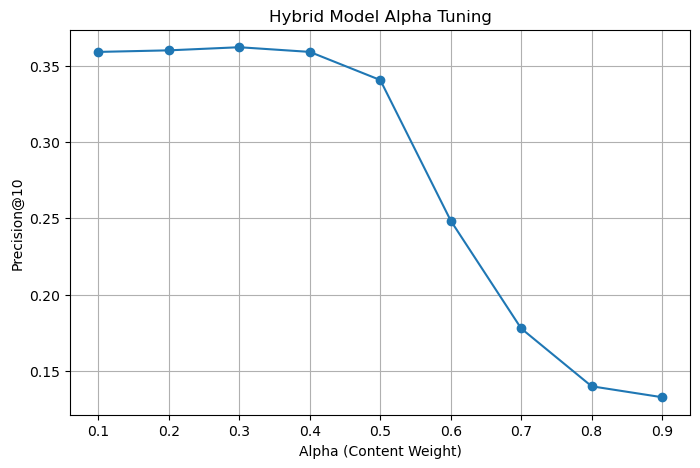

In [94]:
# ------------------------------------------------------------------
# ALPHA TUNING SONUÇLARINI GRAFİKLE GÖSTERME
# ------------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(alpha_results["alpha"], alpha_results["precision_at_10"], marker="o")
plt.xlabel("Alpha (Content Weight)")
plt.ylabel("Precision@10")
plt.title("Hybrid Model Alpha Tuning")
plt.grid(True)
plt.show()

In [95]:
# ------------------------------------------------------------------
# FINAL HYBRID MODEL EVALUATION (FULL TEST SET)
#
# En iyi alpha değeri ile (0.3) modelin gerçek performansını ölçüyoruz.
# ------------------------------------------------------------------

precision_at_k(
    lambda user_id, top_n=10: hybrid_model_wrapper(user_id, top_n=top_n, alpha=0.3),
    train_df,
    test_df,
    k=10
)

Precision@10: 0.3584
Hit sayısı: 14155
Kullanılan kullanıcı: 39492
Skip edilen kullanıcı: 683


0.35842702319457104

In [96]:
# ------------------------------------------------------------------
# HIT RATE@10 HESAPLAMA
#
# Amaç:
# Modelin her kullanıcı için en az 1 doğru ürünü önerip önermediğini
# ölçmek.
# ------------------------------------------------------------------

def hit_rate_at_k(model_func, train_df, test_df, k=10):

    hits = 0
    total_users = 0

    for user_id in test_df["author_id"].unique():

        # model öneri üret
        recs = model_func(user_id, top_n=k)

        if recs is None:
            continue

        # testteki gerçek ürün
        true_items = set(
            test_df[test_df["author_id"] == user_id]["product_id"]
        )

        recommended_items = set(recs["product_id"])

        # en az 1 doğru varsa hit
        if len(true_items & recommended_items) > 0:
            hits += 1

        total_users += 1

    hit_rate = hits / total_users if total_users > 0 else 0

    print(f"Hit Rate@{k}: {hit_rate:.4f}")
    print("Hit sayısı:", hits)
    print("Toplam kullanıcı:", total_users)

    return hit_rate

In [97]:
# ------------------------------------------------------------------
# HYBRID MODEL İÇİN HIT RATE@10
# ------------------------------------------------------------------

hit_rate_at_k(
    lambda user_id, top_n=10: hybrid_model_wrapper(user_id, top_n=top_n, alpha=0.3),
    train_df,
    test_df,
    k=10
)

Hit Rate@10: 0.3584
Hit sayısı: 14155
Toplam kullanıcı: 39492


0.35842702319457104

In [98]:
# ------------------------------------------------------------------
# NDCG@K HESAPLAMA
#
# Amaç:
# Model doğru ürünü önerdiyse, bunu listenin hangi sırasında verdiğini
# dikkate alarak değerlendirme yapmak.
#
# Mantık:
# - Doğru ürün 1. sıradaysa daha yüksek puan
# - Daha alt sıralardaysa daha düşük puan
# - Hiç yoksa 0 puan
#
# Bu setup'ta her kullanıcı için 1 test item olduğu için:
# DCG = 1 / log2(rank + 1)  (doğru ürün bulunursa)
# IDCG = 1                  (ideal durumda doğru ürün 1. sırada olur)
# NDCG = DCG / IDCG = DCG
# ------------------------------------------------------------------

import numpy as np

def ndcg_at_k(model_func, test_df, k=10):

    user_to_true_items = (
        test_df.groupby("author_id")["product_id"]
        .apply(set)
        .to_dict()
    )

    ndcg_scores = []
    total_users = 0

    for user_id, true_items in user_to_true_items.items():

        recs = model_func(user_id, top_n=k)

        if recs is None or len(recs) == 0:
            continue

        recommended_items = list(recs["product_id"].values)

        # Her kullanıcı için yalnızca 1 test item var ama yine de set mantığıyla gidiyoruz
        dcg = 0.0

        for rank, item in enumerate(recommended_items, start=1):
            if item in true_items:
                dcg = 1 / np.log2(rank + 1)
                break

        # Bu setup'ta ideal durumda doğru ürün 1. sırada olur
        idcg = 1.0

        ndcg = dcg / idcg
        ndcg_scores.append(ndcg)
        total_users += 1

    mean_ndcg = np.mean(ndcg_scores) if len(ndcg_scores) > 0 else 0

    print(f"NDCG@{k}: {mean_ndcg:.4f}")
    print("Kullanıcı sayısı:", total_users)

    return mean_ndcg

In [99]:
# ------------------------------------------------------------------
# HYBRID MODEL İÇİN NDCG@10
#
# En iyi alpha değeri olan 0.3 ile hybrid modelin ranking kalitesini
# ölçüyoruz.
# ------------------------------------------------------------------

ndcg_at_k(
    lambda user_id, top_n=10: hybrid_model_wrapper(user_id, top_n=top_n, alpha=0.3),
    test_df,
    k=10
)

NDCG@10: 0.2934
Kullanıcı sayısı: 39492


0.29335118312078634

In [100]:
# ------------------------------------------------------------------
# MODEL EVALUATION HELPER (ROBUST)
# ------------------------------------------------------------------

def evaluate_model(model_name, model_func):

    print(f"\nEvaluating: {model_name}")

    precision = precision_at_k(
        model_func,
        train_df,
        test_df_sample,
        k=10
    )

    hit_rate = precision

    # Eğer model hiç kullanıcı evaluate edemediyse NDCG'yi 0 yaz
    if precision == 0:
        ndcg = 0
        print("NDCG hesaplanmadı çünkü model hiç kullanıcı için öneri üretemedi.")
    else:
        ndcg = ndcg_at_k(
            model_func,
            test_df_sample,
            k=10
        )

    return {
        "model": model_name,
        "precision@10": precision,
        "hit_rate@10": hit_rate,
        "ndcg@10": ndcg
    }

In [101]:
# ------------------------------------------------------------------
# MODEL WRAPPERS
# ------------------------------------------------------------------

pop_model = lambda user_id, top_n=10: popularity_model_wrapper(user_id, top_n=top_n)

content_model = lambda user_id, top_n=10: content_model_wrapper(user_id, top_n=top_n)

cf_model = lambda user_id, top_n=10: cf_model_wrapper(user_id, top_n=top_n)

hybrid_model = lambda user_id, top_n=10: hybrid_model_wrapper(user_id, top_n=top_n, alpha=0.3)

In [102]:
# ------------------------------------------------------------------
# TÜM MODELLERİ EVALUATE ET
# ------------------------------------------------------------------

results = []

results.append(evaluate_model("Popularity", pop_model))
results.append(evaluate_model("Content-Based", content_model))
results.append(evaluate_model("Collaborative Filtering", cf_model))
results.append(evaluate_model("Hybrid (alpha=0.3)", hybrid_model))

results_df = pd.DataFrame(results)

results_df


Evaluating: Popularity
Precision@10: 0.0010
Hit sayısı: 1
Kullanılan kullanıcı: 1000
Skip edilen kullanıcı: 0
NDCG@10: 0.0003
Kullanıcı sayısı: 1000

Evaluating: Content-Based
Precision@10: 0.1247
Hit sayısı: 122
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.0991
Kullanıcı sayısı: 978

Evaluating: Collaborative Filtering
Precision@10: 0.3550
Hit sayısı: 355
Kullanılan kullanıcı: 1000
Skip edilen kullanıcı: 0
NDCG@10: 0.2936
Kullanıcı sayısı: 1000

Evaluating: Hybrid (alpha=0.3)
Precision@10: 0.3620
Hit sayısı: 354
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.2989
Kullanıcı sayısı: 978


,model,precision@10,hit_rate@10,ndcg@10
0,Popularity,0.001000,0.001000,0.000333
1,Content-Based,0.124744,0.124744,0.099134
2,Collaborative Filtering,0.355000,0.355000,0.293644
3,Hybrid (alpha=0.3),0.361963,0.361963,0.298871


In [103]:
# SAMPLE evaluation için küçük test set
sample_user_ids = test_df["author_id"].unique()[:1000]

test_df_sample = test_df[
    test_df["author_id"].isin(sample_user_ids)
].copy()

print("Sample kullanıcı:", test_df_sample["author_id"].nunique())

Sample kullanıcı: 1000


In [104]:
results_df.to_csv("../outputs/model_comparison_sample.csv", index=False)

In [105]:
results_df.to_csv("../outputs/model_comparison_final.csv", index=False)

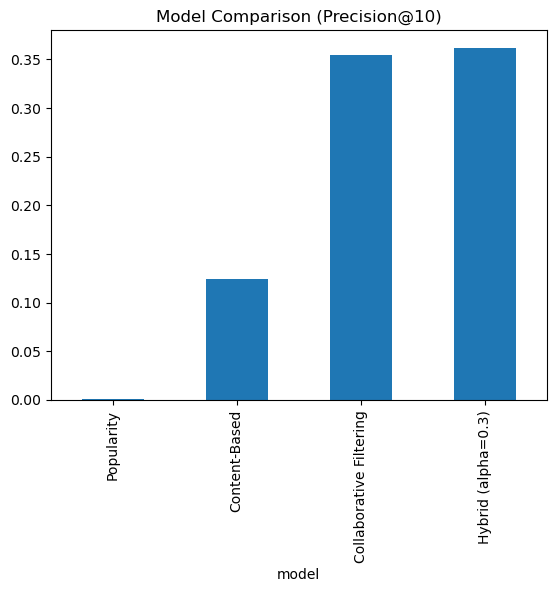

In [106]:
import matplotlib.pyplot as plt

results_df.set_index("model")["precision@10"].plot(kind="bar")
plt.title("Model Comparison (Precision@10)")
plt.show()

In [108]:
# ------------------------------------------------------------------
# SBERT İÇİN GEREKLİ IMPORTLAR
# ------------------------------------------------------------------

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

/opt/anaconda3/envs/lightfm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [109]:
# ------------------------------------------------------------------
# SBERT İÇİN ÜRÜN TABLOSUNU YÜKLEME
# ------------------------------------------------------------------

products_clean = pd.read_csv("../data_interim/products_clean.csv")

# product_id ve product_text tarafını güvene al
products_clean["product_id"] = products_clean["product_id"].astype(str)
products_clean["product_text"] = products_clean["product_text"].fillna("")

print("products_clean shape:", products_clean.shape)
print("product_text var mı?:", "product_text" in products_clean.columns)
products_clean[["product_id", "product_name", "product_text"]].head(3)

products_clean shape: (8494, 19)
product_text var mı?: True


,product_id,product_name,product_text
0,P473671,Fragrance Discovery Set,Fragrance Discovery Set 19-69 Fragrance Value ...
1,P473668,La Habana Eau de Parfum,La Habana Eau de Parfum 19-69 Fragrance Women ...
2,P473662,Rainbow Bar Eau de Parfum,Rainbow Bar Eau de Parfum 19-69 Fragrance Wome...


In [110]:
# ------------------------------------------------------------------
# PRODUCT_ID TİPLERİNİ EŞİTLEME
# ------------------------------------------------------------------

train_df["product_id"] = train_df["product_id"].astype(str)
test_df["product_id"] = test_df["product_id"].astype(str)
test_df_sample["product_id"] = test_df_sample["product_id"].astype(str)

print("Tip eşitleme tamam.")
print("train_df product_id tipi:", train_df["product_id"].dtype)
print("products_clean product_id tipi:", products_clean["product_id"].dtype)

Tip eşitleme tamam.
train_df product_id tipi: object
products_clean product_id tipi: object


In [111]:
# ------------------------------------------------------------------
# SBERT MODELİNİ YÜKLEME
# ------------------------------------------------------------------

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10521.00it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [112]:
# ------------------------------------------------------------------
# PRODUCT_TEXT İÇİN SBERT EMBEDDING OLUŞTURMA
# ------------------------------------------------------------------

product_texts = products_clean["product_text"].tolist()

embeddings = sbert_model.encode(
    product_texts,
    show_progress_bar=True
)

print("Embedding shape:", np.array(embeddings).shape)

Batches: 100%|██████████| 266/266 [00:35<00:00,  7.48it/s]

Embedding shape: (8494, 384)


In [113]:
# ------------------------------------------------------------------
# SBERT SIMILARITY MATRIX
# ------------------------------------------------------------------

similarity_matrix_sbert = cosine_similarity(embeddings)

print("SBERT similarity matrix shape:", similarity_matrix_sbert.shape)

SBERT similarity matrix shape: (8494, 8494)


In [114]:
# ------------------------------------------------------------------
# PRODUCT_ID <-> INDEX MAPPING
# ------------------------------------------------------------------

productid_to_index_sbert = pd.Series(
    products_clean.index,
    index=products_clean["product_id"]
).to_dict()

index_to_productid_sbert = dict(zip(products_clean.index, products_clean["product_id"]))

print("Mapping boyutu:", len(productid_to_index_sbert))
print("Örnek product_id:", products_clean["product_id"].iloc[0])

Mapping boyutu: 8494
Örnek product_id: P473671


In [115]:
# ------------------------------------------------------------------
# SEED ITEM KONTROLÜ
# ------------------------------------------------------------------

sample_user_id = test_df_sample.iloc[0]["author_id"]
seed_item = get_seed_item_for_user(sample_user_id)

print("Sample user:", sample_user_id)
print("Seed item:", seed_item)
print("Seed item mapping içinde var mı?:", seed_item in productid_to_index_sbert)

Sample user: 10000117144
Seed item: P504794
Seed item mapping içinde var mı?: True


In [116]:
# ------------------------------------------------------------------
# SBERT CONTENT WRAPPER (EVALUATION İÇİN)
# ------------------------------------------------------------------

def content_model_sbert_wrapper(user_id, top_n=10):

    seed_item = get_seed_item_for_user(user_id)

    if seed_item is None:
        return None

    seed_item = str(seed_item)

    if seed_item not in productid_to_index_sbert:
        return None

    idx = productid_to_index_sbert[seed_item]

    similarity_scores = list(enumerate(similarity_matrix_sbert[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:]  # seed item'ın kendisini çıkar

    train_items = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"].astype(str)
    )

    results = []

    for i, score in similarity_scores:
        product_id = index_to_productid_sbert[i]

        if product_id in train_items:
            continue

        results.append({
            "product_id": product_id,
            "similarity_score": score
        })

        if len(results) >= top_n:
            break

    if len(results) == 0:
        return None

    return pd.DataFrame(results)

In [117]:
# ------------------------------------------------------------------
# SBERT WRAPPER TEK KULLANICI TESTİ
# ------------------------------------------------------------------

content_model_sbert_wrapper(sample_user_id, top_n=10)

,product_id,similarity_score
0,P474829,0.839127
1,P504773,0.834888
2,P438620,0.833744
3,P447200,0.833298
4,P503652,0.829657
5,P468354,0.829506
6,P248407,0.824031
7,P504810,0.821855
8,P505016,0.819787
9,P375534,0.815016


In [118]:
# ------------------------------------------------------------------
# EVALUATION İÇİN SBERT MODEL WRAPPER
# ------------------------------------------------------------------

content_sbert_model = lambda user_id, top_n=10: content_model_sbert_wrapper(user_id, top_n=top_n)

In [119]:
# ------------------------------------------------------------------
# CONTENT-BASED (SBERT) EVALUATION
# ------------------------------------------------------------------

evaluate_model("Content-Based (SBERT)", content_sbert_model)


Evaluating: Content-Based (SBERT)
Precision@10: 0.0982
Hit sayısı: 96
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.0863
Kullanıcı sayısı: 978


{'model': 'Content-Based (SBERT)',
 'precision@10': 0.09815950920245399,
 'hit_rate@10': 0.09815950920245399,
 'ndcg@10': 0.08628038783514048}

In [120]:
# ------------------------------------------------------------------
# LIGHTFM KURULUMU
# ------------------------------------------------------------------

!pip install lightfm

In [121]:
from lightfm import LightFM
from lightfm.data import Dataset
import pandas as pd
import numpy as np

In [122]:
train_positive = train_df[train_df["rating"] >= 4].copy()
test_positive = test_df[test_df["rating"] >= 4].copy()

train_positive["author_id"] = train_positive["author_id"].astype(str)
train_positive["product_id"] = train_positive["product_id"].astype(str)

test_positive["author_id"] = test_positive["author_id"].astype(str)
test_positive["product_id"] = test_positive["product_id"].astype(str)

In [123]:
dataset = Dataset()

all_users = train_positive["author_id"].unique().tolist()
all_items = train_positive["product_id"].unique().tolist()

dataset.fit(
    users=all_users,
    items=all_items
)

In [124]:
# ------------------------------------------------------------------
# LIGHTFM INTERACTION MATRIX
# ------------------------------------------------------------------

(interactions, weights) = dataset.build_interactions(
    [(row["author_id"], row["product_id"]) for _, row in train_positive.iterrows()]
)

print("Interaction matrix shape:", interactions.shape)

Interaction matrix shape: (39492, 2192)


In [125]:
# ------------------------------------------------------------------
# LIGHTFM ITEM FEATURE MATRIX
# ------------------------------------------------------------------

item_feature_cols = [
    "product_id",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

lightfm_items = products_clean[item_feature_cols].copy()

lightfm_items["product_id"] = lightfm_items["product_id"].astype(str)

for col in ["brand_name", "primary_category", "secondary_category", "tertiary_category"]:
    lightfm_items[col] = lightfm_items[col].fillna("unknown").astype(str)

feature_tokens = []

for _, row in lightfm_items.iterrows():
    feature_tokens.extend([
        f"brand:{row['brand_name']}",
        f"primary:{row['primary_category']}",
        f"secondary:{row['secondary_category']}",
        f"tertiary:{row['tertiary_category']}"
    ])

feature_tokens = list(set(feature_tokens))

print("Toplam item feature token sayısı:", len(feature_tokens))
lightfm_items.head()

Toplam item feature token sayısı: 474


,product_id,brand_name,primary_category,secondary_category,tertiary_category
0,P473671,19-69,Fragrance,Value & Gift Sets,Perfume Gift Sets
1,P473668,19-69,Fragrance,Women,Perfume
2,P473662,19-69,Fragrance,Women,Perfume
3,P473660,19-69,Fragrance,Women,Perfume
4,P473658,19-69,Fragrance,Women,Perfume


In [126]:
# ------------------------------------------------------------------
# DATASET'İ ITEM FEATURE'LARLA YENİDEN FIT ETME
# ------------------------------------------------------------------

dataset = Dataset()

all_users = train_positive["author_id"].unique().tolist()
all_items = lightfm_items["product_id"].unique().tolist()

dataset.fit(
    users=all_users,
    items=all_items,
    item_features=feature_tokens
)

print("Dataset fit tamamlandı")
print("Kullanıcı sayısı:", len(all_users))
print("Ürün sayısı:", len(all_items))
print("Feature token sayısı:", len(feature_tokens))

Dataset fit tamamlandı
Kullanıcı sayısı: 39492
Ürün sayısı: 8494
Feature token sayısı: 474


In [127]:
# ------------------------------------------------------------------
# INTERACTION MATRIX'İ YENİDEN OLUŞTURMA
# ------------------------------------------------------------------

(interactions, weights) = dataset.build_interactions(
    [(row["author_id"], row["product_id"]) for _, row in train_positive.iterrows()]
)

print("Interaction matrix shape:", interactions.shape)

Interaction matrix shape: (39492, 8494)


In [128]:
# ------------------------------------------------------------------
# ITEM FEATURE MATRIX OLUŞTURMA
# ------------------------------------------------------------------

item_feature_tuples = []

for _, row in lightfm_items.iterrows():
    item_feature_tuples.append(
        (
            row["product_id"],
            [
                f"brand:{row['brand_name']}",
                f"primary:{row['primary_category']}",
                f"secondary:{row['secondary_category']}",
                f"tertiary:{row['tertiary_category']}"
            ]
        )
    )

item_features_matrix = dataset.build_item_features(item_feature_tuples)

print("Item feature matrix shape:", item_features_matrix.shape)

Item feature matrix shape: (8494, 8968)


In [129]:
# ------------------------------------------------------------------
# LIGHTFM MODEL TANIMI
# ------------------------------------------------------------------

lightfm_model = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.05,
    random_state=42
)

print("Model tanımlandı")

Model tanımlandı


In [130]:
# ------------------------------------------------------------------
# LIGHTFM MODEL EĞİTİMİ
# ------------------------------------------------------------------

lightfm_model.fit(
    interactions=interactions,
    item_features=item_features_matrix,
    epochs=10,
    num_threads=4
)

print("LightFM training tamamlandı")

LightFM training tamamlandı


In [131]:
# ------------------------------------------------------------------
# LIGHTFM RECOMMENDATION FUNCTION
# ------------------------------------------------------------------

def recommend_lightfm_products(user_id, top_n=10):

    user_id = str(user_id)

    try:
        user_index = dataset.mapping()[0][user_id]
    except KeyError:
        return None

    scores = lightfm_model.predict(
        user_ids=user_index,
        item_ids=np.arange(len(dataset.mapping()[2])),
        item_features=item_features_matrix
    )

    item_id_map = dataset.mapping()[2]
    index_to_item = {v: k for k, v in item_id_map.items()}

    ranked_items = np.argsort(-scores)

    train_items = set(
        train_positive.loc[train_positive["author_id"] == user_id, "product_id"]
    )

    results = []

    for idx in ranked_items:
        product_id = index_to_item[idx]

        if product_id in train_items:
            continue

        results.append({
            "product_id": product_id,
            "score": scores[idx]
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [132]:
result = recommend_lightfm_products("P422077", top_n=10)
result

In [133]:
random_user = train_positive["author_id"].iloc[0]
recommend_lightfm_products(random_user, top_n=10)

,product_id,score
0,P427417,2.692383
1,P427419,2.508593
2,P442563,2.466110
3,P248407,2.298129
4,P455369,2.226761
5,P427413,2.163215
6,P427414,2.156516
7,P427420,2.106700
8,P427416,2.076944
9,P479354,2.030334


In [134]:
# ------------------------------------------------------------------
# LIGHTFM MODEL WRAPPER
# ------------------------------------------------------------------

lightfm_model_wrapper = lambda user_id, top_n=10: recommend_lightfm_products(user_id, top_n=top_n)

In [135]:
# ------------------------------------------------------------------
# LIGHTFM EVALUATION
# ------------------------------------------------------------------

evaluate_model("LightFM", lightfm_model_wrapper)


Evaluating: LightFM
Precision@10: 0.2382
Hit sayısı: 233
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1542
Kullanıcı sayısı: 978


{'model': 'LightFM',
 'precision@10': 0.23824130879345604,
 'hit_rate@10': 0.23824130879345604,
 'ndcg@10': 0.154218170704642}

In [136]:
lightfm_result = {
    "model": "LightFM",
    "precision@10": 0.23824130879345604,
    "hit_rate@10": 0.23824130879345604,
    "ndcg@10": 0.154218170704642
}

lightfm_result

{'model': 'LightFM',
 'precision@10': 0.23824130879345604,
 'hit_rate@10': 0.23824130879345604,
 'ndcg@10': 0.154218170704642}

In [137]:
# ------------------------------------------------------------------
# LIGHTFM TRAIN + EVALUATE FONKSİYONU
#
# Amaç:
# Verilen LightFM parametreleri ile modeli eğitmek ve sample test set
# üzerinde evaluation yapmak.
# ------------------------------------------------------------------

def train_and_evaluate_lightfm(
    loss,
    no_components,
    epochs,
    learning_rate=0.05
):
    # --------------------------------------------------------------
    # 1) Modeli tanımla
    # --------------------------------------------------------------
    model = LightFM(
        loss=loss,
        no_components=no_components,
        learning_rate=learning_rate,
        random_state=42
    )

    # --------------------------------------------------------------
    # 2) Modeli eğit
    # --------------------------------------------------------------
    model.fit(
        interactions=interactions,
        item_features=item_features_matrix,
        epochs=epochs,
        num_threads=4
    )

    # --------------------------------------------------------------
    # 3) Bu model için recommendation fonksiyonu tanımla
    # --------------------------------------------------------------
    def recommend_lightfm_products_tuned(user_id, top_n=10):

        user_id = str(user_id)

        # Kullanıcı training mapping içinde yoksa öneri üretemeyiz
        try:
            user_index = dataset.mapping()[0][user_id]
        except KeyError:
            return None

        # Tüm item'lar için skor üret
        scores = model.predict(
            user_ids=user_index,
            item_ids=np.arange(len(dataset.mapping()[2])),
            item_features=item_features_matrix
        )

        # Item index -> product_id dönüşümü
        item_id_map = dataset.mapping()[2]
        index_to_item = {v: k for k, v in item_id_map.items()}

        # Skorları büyükten küçüğe sırala
        ranked_items = np.argsort(-scores)

        # Kullanıcının train'de zaten etkileştiği ürünleri çıkar
        train_items = set(
            train_positive.loc[train_positive["author_id"] == user_id, "product_id"]
        )

        results = []

        for idx in ranked_items:
            product_id = index_to_item[idx]

            if product_id in train_items:
                continue

            results.append({
                "product_id": product_id,
                "score": scores[idx]
            })

            if len(results) >= top_n:
                break

        return pd.DataFrame(results)

    # --------------------------------------------------------------
    # 4) Evaluation
    # Not:
    # evaluate_model şu anda sample test set üzerinden çalışıyor.
    # --------------------------------------------------------------
    result = evaluate_model(
        model_name=f"LightFM | loss={loss}, comp={no_components}, epochs={epochs}",
        model_func=recommend_lightfm_products_tuned
    )

    return result

In [138]:
# ------------------------------------------------------------------
# LIGHTFM HYPERPARAMETER ARAMA UZAYI
# ------------------------------------------------------------------

loss_values = ["warp", "bpr"]
component_values = [32, 64]
epoch_values = [10, 20]

In [139]:
# ------------------------------------------------------------------
# LIGHTFM HYPERPARAMETER TUNING
# ------------------------------------------------------------------

lightfm_tuning_results = []

for loss in loss_values:
    for no_components in component_values:
        for epochs in epoch_values:

            print("\n" + "=" * 70)
            print(f"Test ediliyor -> loss={loss}, no_components={no_components}, epochs={epochs}")
            print("=" * 70)

            result = train_and_evaluate_lightfm(
                loss=loss,
                no_components=no_components,
                epochs=epochs,
                learning_rate=0.05
            )

            lightfm_tuning_results.append(result)

lightfm_tuning_df = pd.DataFrame(lightfm_tuning_results)

lightfm_tuning_df


Test ediliyor -> loss=warp, no_components=32, epochs=10

Evaluating: LightFM | loss=warp, comp=32, epochs=10
Precision@10: 0.2239
Hit sayısı: 219
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1340
Kullanıcı sayısı: 978

Test ediliyor -> loss=warp, no_components=32, epochs=20

Evaluating: LightFM | loss=warp, comp=32, epochs=20
Precision@10: 0.2393
Hit sayısı: 234
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1512
Kullanıcı sayısı: 978

Test ediliyor -> loss=warp, no_components=64, epochs=10

Evaluating: LightFM | loss=warp, comp=64, epochs=10
Precision@10: 0.2382
Hit sayısı: 233
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1542
Kullanıcı sayısı: 978

Test ediliyor -> loss=warp, no_components=64, epochs=20

Evaluating: LightFM | loss=warp, comp=64, epochs=20
Precision@10: 0.2771
Hit sayısı: 271
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1763
Kullanıcı sayısı: 978

Test ediliyor -> loss=bpr, no_components=32, epochs

,model,precision@10,hit_rate@10,ndcg@10
0,"LightFM | loss=warp, comp=32, epochs=10",0.223926,0.223926,0.134036
1,"LightFM | loss=warp, comp=32, epochs=20",0.239264,0.239264,0.151158
2,"LightFM | loss=warp, comp=64, epochs=10",0.238241,0.238241,0.154218
3,"LightFM | loss=warp, comp=64, epochs=20",0.277096,0.277096,0.176296
4,"LightFM | loss=bpr, comp=32, epochs=10",0.058282,0.058282,0.037747
5,"LightFM | loss=bpr, comp=32, epochs=20",0.094070,0.094070,0.063354
6,"LightFM | loss=bpr, comp=64, epochs=10",0.065440,0.065440,0.045251
7,"LightFM | loss=bpr, comp=64, epochs=20",0.102249,0.102249,0.069197


In [140]:
# ------------------------------------------------------------------
# LIGHTFM TUNING SONUÇLARINI SIRALA
# ------------------------------------------------------------------

lightfm_tuning_df = lightfm_tuning_df.sort_values(
    by=["precision@10", "ndcg@10"],
    ascending=False
)

lightfm_tuning_df

,model,precision@10,hit_rate@10,ndcg@10
3,"LightFM | loss=warp, comp=64, epochs=20",0.277096,0.277096,0.176296
1,"LightFM | loss=warp, comp=32, epochs=20",0.239264,0.239264,0.151158
2,"LightFM | loss=warp, comp=64, epochs=10",0.238241,0.238241,0.154218
0,"LightFM | loss=warp, comp=32, epochs=10",0.223926,0.223926,0.134036
7,"LightFM | loss=bpr, comp=64, epochs=20",0.102249,0.102249,0.069197
5,"LightFM | loss=bpr, comp=32, epochs=20",0.094070,0.094070,0.063354
6,"LightFM | loss=bpr, comp=64, epochs=10",0.065440,0.065440,0.045251
4,"LightFM | loss=bpr, comp=32, epochs=10",0.058282,0.058282,0.037747


In [141]:
# ------------------------------------------------------------------
# EN İYİ LIGHTFM KONFİGÜRASYONU
# ------------------------------------------------------------------

best_lightfm_result = lightfm_tuning_df.iloc[0]

print("En iyi LightFM sonucu:")
print(best_lightfm_result)

En iyi LightFM sonucu:
model           LightFM | loss=warp, comp=64, epochs=20
precision@10                                   0.277096
hit_rate@10                                    0.277096
ndcg@10                                        0.176296
Name: 3, dtype: object


In [142]:
# ------------------------------------------------------------------
# LIGHTFM İÇİN PRODUCT DATA YÜKLE
# ------------------------------------------------------------------

products_clean = pd.read_csv("../data_interim/products_clean.csv")

products_clean["product_id"] = products_clean["product_id"].astype(str)

products_clean.shape

(8494, 19)

In [143]:
# ------------------------------------------------------------------
# HIGHLIGHTS + INGREDIENTS TEMİZLEME
# ------------------------------------------------------------------

import ast

def clean_list_column(col):
    cleaned = []

    for val in col:
        if pd.isna(val):
            cleaned.append([])
            continue
        
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                cleaned.append([str(x).lower().strip() for x in parsed])
            else:
                cleaned.append([])
        except:
            cleaned.append([])

    return cleaned


products_clean["highlights_clean"] = clean_list_column(products_clean["highlights"])
products_clean["ingredients_clean"] = clean_list_column(products_clean["ingredients"])

products_clean[["product_id", "highlights_clean", "ingredients_clean"]].head()

,product_id,highlights_clean,ingredients_clean
0,P473671,[],[]
1,P473668,[],[]
2,P473662,[],[]
3,P473660,[],[]
4,P473658,[],[]


In [144]:
# ------------------------------------------------------------------
# TOKEN SET OLUŞTUR
# ------------------------------------------------------------------

all_highlight_tokens = set()
all_ingredient_tokens = set()

for _, row in products_clean.iterrows():
    all_highlight_tokens.update(row["highlights_clean"])
    all_ingredient_tokens.update(row["ingredients_clean"])

print("Highlight token sayısı:", len(all_highlight_tokens))
print("Ingredient token sayısı:", len(all_ingredient_tokens))

Highlight token sayısı: 0
Ingredient token sayısı: 0


In [145]:
# ------------------------------------------------------------------
# ROBUST LIST PARSER (FIXED VERSION)
# ------------------------------------------------------------------

def parse_feature_column(val):

    if pd.isna(val):
        return []

    # zaten listeyse
    if isinstance(val, list):
        return [str(x).lower().strip() for x in val if str(x).strip()]

    val = str(val).strip()

    if not val:
        return []

    # liste gibi string ise
    if val.startswith("[") and val.endswith("]"):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [str(x).lower().strip() for x in parsed if str(x).strip()]
        except:
            pass

    # virgülle ayrılmışsa
    if "," in val:
        return [x.strip().lower() for x in val.split(",") if x.strip()]

    # tek string ise
    return [val.lower()]

In [146]:
products_clean["highlights_clean"] = products_clean["highlights"].apply(parse_feature_column)
products_clean["ingredients_clean"] = products_clean["ingredients"].apply(parse_feature_column)

In [147]:
products_clean[["highlights", "highlights_clean"]].head(5)

,highlights,highlights_clean
0,Unisex/ Genderless Scent Warm &Spicy Scent Woo...,[unisex/ genderless scent warm &spicy scent wo...
1,Unisex/ Genderless Scent Layerable Scent Warm ...,[unisex/ genderless scent layerable scent warm...
2,Unisex/ Genderless Scent Layerable Scent Woody...,[unisex/ genderless scent layerable scent wood...
3,Unisex/ Genderless Scent Layerable Scent Warm ...,[unisex/ genderless scent layerable scent warm...
4,Unisex/ Genderless Scent Layerable Scent Woody...,[unisex/ genderless scent layerable scent wood...


In [148]:
all_highlight_tokens = set()
all_ingredient_tokens = set()

for _, row in products_clean.iterrows():
    all_highlight_tokens.update(row["highlights_clean"])
    all_ingredient_tokens.update(row["ingredients_clean"])

print("Highlight token sayısı:", len(all_highlight_tokens))
print("Ingredient token sayısı:", len(all_ingredient_tokens))

Highlight token sayısı: 4474
Ingredient token sayısı: 17845


In [149]:
# ------------------------------------------------------------------
# TOKEN FREKANSLARINI HESAPLA
# ------------------------------------------------------------------

from collections import Counter

highlight_counter = Counter()
ingredient_counter = Counter()

for _, row in products_clean.iterrows():
    highlight_counter.update(row["highlights_clean"])
    ingredient_counter.update(row["ingredients_clean"])

print("En sık 20 highlight token:")
print(highlight_counter.most_common(20))

print("\nEn sık 20 ingredient token:")
print(ingredient_counter.most_common(20))

En sık 20 highlight token:
[('combo', 897), ('normal skin', 391), ('normal skin cruelty-free', 102), ('best for oily', 66), ('layerable scent floral scent', 64), ('best for dry', 51), ('vegan unisex/ genderless scent clean at sephora cruelty-free', 48), ('normal skin without sulfates sls & sles', 42), ('vegan cruelty-free', 40), ('vegan without phthalates without parabens without sulfates sls & sles cruelty-free', 40), ('floral scent layerable scent', 37), ('vegan', 32), ('normal skin best for dry', 25), ('normal skin niacinamide', 21), ('vegan unisex/ genderless scent clean + planet positive without phthalates hypoallergenic cruelty-free', 21), ('clean at sephora vegan', 20), ('clean at sephora', 19), ('vegan clean at sephora', 19), ('floral scent', 18), ('clean at sephora good for: dryness', 18)]

En sık 20 ingredient token:
[('glycerin', 4252), ('phenoxyethanol', 3926), ('caprylyl glycol', 2803), ('tocopherol', 2756), ('limonene', 2587), ('ethylhexylglycerin', 2429), ('linalool', 23

In [150]:
# ------------------------------------------------------------------
# KULLANILACAK TOKEN SETLERİ
# ------------------------------------------------------------------

top_highlight_tokens = {
    token for token, count in highlight_counter.most_common(100)
}

top_ingredient_tokens = {
    token for token, count in ingredient_counter.most_common(200)
}

print("Seçilen highlight token sayısı:", len(top_highlight_tokens))
print("Seçilen ingredient token sayısı:", len(top_ingredient_tokens))

Seçilen highlight token sayısı: 100
Seçilen ingredient token sayısı: 200


In [152]:
# ------------------------------------------------------------------
# FEATURE LIST OLUŞTUR
# ------------------------------------------------------------------
import re
lightfm_items_fe = products_clean[
    [
        "product_id",
        "brand_name",
        "primary_category",
        "secondary_category",
        "tertiary_category",
        "highlights_clean",
        "ingredients_clean"
    ]
].copy()

lightfm_items_fe["product_id"] = lightfm_items_fe["product_id"].astype(str)

for col in ["brand_name", "primary_category", "secondary_category", "tertiary_category"]:
    lightfm_items_fe[col] = lightfm_items_fe[col].fillna("unknown").astype(str)

def normalize_token(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s\-/+]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.replace(" ", "_")

def build_feature_list(row):
    features = []

    # temel feature'lar
    features.append(f"brand:{normalize_token(row['brand_name'])}")
    features.append(f"primary:{normalize_token(row['primary_category'])}")
    features.append(f"secondary:{normalize_token(row['secondary_category'])}")
    features.append(f"tertiary:{normalize_token(row['tertiary_category'])}")

    # highlight token'ları
    for token in row["highlights_clean"]:
        if token in top_highlight_tokens:
            features.append(f"highlight:{normalize_token(token)}")

    # ingredient token'ları
    for token in row["ingredients_clean"]:
        if token in top_ingredient_tokens:
            features.append(f"ingredient:{normalize_token(token)}")

    return list(set(features))

lightfm_items_fe["feature_list"] = lightfm_items_fe.apply(build_feature_list, axis=1)

lightfm_items_fe[["product_id", "feature_list"]].head()

,product_id,feature_list
0,P473671,"[ingredient:coumarin, ingredient:farnesol, ing..."
1,P473668,"[secondary:women, tertiary:perfume, ingredient..."
2,P473662,"[secondary:women, tertiary:perfume, ingredient..."
3,P473660,"[secondary:women, tertiary:perfume, ingredient..."
4,P473658,"[secondary:women, tertiary:perfume, ingredient..."


In [153]:
# ------------------------------------------------------------------
# TÜM ENGINEERED FEATURE TOKEN'LARINI TOPLA
# ------------------------------------------------------------------

feature_tokens_fe = sorted(
    list(
        set(
            token
            for feature_list in lightfm_items_fe["feature_list"]
            for token in feature_list
        )
    )
)

print("Toplam engineered feature token sayısı:", len(feature_tokens_fe))

Toplam engineered feature token sayısı: 771


In [154]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED DATASET
# ------------------------------------------------------------------

dataset_fe = Dataset()

all_users_fe = train_positive["author_id"].unique().tolist()
all_items_fe = lightfm_items_fe["product_id"].unique().tolist()

dataset_fe.fit(
    users=all_users_fe,
    items=all_items_fe,
    item_features=feature_tokens_fe
)

print("Dataset FE fit tamamlandı")
print("Kullanıcı sayısı:", len(all_users_fe))
print("Ürün sayısı:", len(all_items_fe))
print("Feature token sayısı:", len(feature_tokens_fe))

Dataset FE fit tamamlandı
Kullanıcı sayısı: 39492
Ürün sayısı: 8494
Feature token sayısı: 771


In [155]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED MATRIX'LER
# ------------------------------------------------------------------

(interactions_fe, weights_fe) = dataset_fe.build_interactions(
    [(row["author_id"], row["product_id"]) for _, row in train_positive.iterrows()]
)

item_feature_tuples_fe = list(
    zip(lightfm_items_fe["product_id"], lightfm_items_fe["feature_list"])
)

item_features_matrix_fe = dataset_fe.build_item_features(item_feature_tuples_fe)

print("Interaction FE shape:", interactions_fe.shape)
print("Item feature FE shape:", item_features_matrix_fe.shape)

Interaction FE shape: (39492, 8494)
Item feature FE shape: (8494, 9265)


In [156]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED LIGHTFM TRAINING
# ------------------------------------------------------------------

lightfm_model_fe = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.05,
    random_state=42
)

lightfm_model_fe.fit(
    interactions=interactions_fe,
    item_features=item_features_matrix_fe,
    epochs=20,
    num_threads=4
)

print("Feature engineered LightFM training tamamlandı")

Feature engineered LightFM training tamamlandı


In [157]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED LIGHTFM RECOMMENDATION FUNCTION
# ------------------------------------------------------------------

def recommend_lightfm_products_fe(user_id, top_n=10):

    user_id = str(user_id)

    try:
        user_index = dataset_fe.mapping()[0][user_id]
    except KeyError:
        return None

    item_id_map = dataset_fe.mapping()[2]
    index_to_item = {v: k for k, v in item_id_map.items()}

    scores = lightfm_model_fe.predict(
        user_ids=user_index,
        item_ids=np.arange(len(item_id_map)),
        item_features=item_features_matrix_fe
    )

    ranked_items = np.argsort(-scores)

    train_items = set(
        train_positive.loc[train_positive["author_id"] == user_id, "product_id"]
    )

    results = []

    for idx in ranked_items:
        product_id = index_to_item[idx]

        if product_id in train_items:
            continue

        results.append({
            "product_id": product_id,
            "score": scores[idx]
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [158]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED LIGHTFM TEK KULLANICI TESTİ
# ------------------------------------------------------------------

random_user = train_positive["author_id"].iloc[0]
recommend_lightfm_products_fe(random_user, top_n=10)

,product_id,score
0,P393718,2.480893
1,P218700,2.192574
2,P410400,2.083538
3,P421275,2.064316
4,P12573,1.953785
5,P420652,1.949503
6,P392245,1.944435
7,P309306,1.914636
8,P427417,1.844917
9,P453816,1.781634


In [159]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED LIGHTFM WRAPPER
# ------------------------------------------------------------------

lightfm_model_fe_wrapper = lambda user_id, top_n=10: recommend_lightfm_products_fe(user_id, top_n=top_n)

In [160]:
# ------------------------------------------------------------------
# FEATURE ENGINEERED LIGHTFM EVALUATION
# ------------------------------------------------------------------

evaluate_model("LightFM (Feature Engineered)", lightfm_model_fe_wrapper)


Evaluating: LightFM (Feature Engineered)
Precision@10: 0.2270
Hit sayısı: 222
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1439
Kullanıcı sayısı: 978


{'model': 'LightFM (Feature Engineered)',
 'precision@10': 0.22699386503067484,
 'hit_rate@10': 0.22699386503067484,
 'ndcg@10': 0.1439459383596097}

In [161]:
# ------------------------------------------------------------------
# SADECE HIGHLIGHT KULLANAN FEATURE LIST
# ------------------------------------------------------------------

lightfm_items_fe2 = products_clean[
    [
        "product_id",
        "brand_name",
        "primary_category",
        "secondary_category",
        "tertiary_category",
        "highlights_clean"
    ]
].copy()

lightfm_items_fe2["product_id"] = lightfm_items_fe2["product_id"].astype(str)

for col in ["brand_name", "primary_category", "secondary_category", "tertiary_category"]:
    lightfm_items_fe2[col] = lightfm_items_fe2[col].fillna("unknown").astype(str)

def build_feature_list_highlight_only(row):
    features = []

    # temel feature'lar
    features.append(f"brand:{normalize_token(row['brand_name'])}")
    features.append(f"primary:{normalize_token(row['primary_category'])}")
    features.append(f"secondary:{normalize_token(row['secondary_category'])}")
    features.append(f"tertiary:{normalize_token(row['tertiary_category'])}")

    # sadece highlight token'ları
    for token in row["highlights_clean"]:
        if token in top_highlight_tokens:
            features.append(f"highlight:{normalize_token(token)}")

    return list(set(features))

lightfm_items_fe2["feature_list"] = lightfm_items_fe2.apply(build_feature_list_highlight_only, axis=1)

lightfm_items_fe2[["product_id", "feature_list"]].head()

,product_id,feature_list
0,P473671,"[primary:fragrance, brand:19-69, tertiary:perf..."
1,P473668,"[secondary:women, tertiary:perfume, primary:fr..."
2,P473662,"[secondary:women, tertiary:perfume, primary:fr..."
3,P473660,"[secondary:women, tertiary:perfume, primary:fr..."
4,P473658,"[secondary:women, tertiary:perfume, primary:fr..."


In [162]:
# ------------------------------------------------------------------
# HIGHLIGHT-ONLY FEATURE TOKEN'LARI
# ------------------------------------------------------------------

feature_tokens_fe2 = sorted(
    list(
        set(
            token
            for feature_list in lightfm_items_fe2["feature_list"]
            for token in feature_list
        )
    )
)

print("Toplam feature token sayısı:", len(feature_tokens_fe2))

Toplam feature token sayısı: 574


In [163]:
# ------------------------------------------------------------------
# HIGHLIGHT-ONLY DATASET VE MATRIX'LER
# ------------------------------------------------------------------

dataset_fe2 = Dataset()

all_users_fe2 = train_positive["author_id"].unique().tolist()
all_items_fe2 = lightfm_items_fe2["product_id"].unique().tolist()

dataset_fe2.fit(
    users=all_users_fe2,
    items=all_items_fe2,
    item_features=feature_tokens_fe2
)

(interactions_fe2, weights_fe2) = dataset_fe2.build_interactions(
    [(row["author_id"], row["product_id"]) for _, row in train_positive.iterrows()]
)

item_feature_tuples_fe2 = list(
    zip(lightfm_items_fe2["product_id"], lightfm_items_fe2["feature_list"])
)

item_features_matrix_fe2 = dataset_fe2.build_item_features(item_feature_tuples_fe2)

print("Interaction FE2 shape:", interactions_fe2.shape)
print("Item feature FE2 shape:", item_features_matrix_fe2.shape)

Interaction FE2 shape: (39492, 8494)
Item feature FE2 shape: (8494, 9068)


In [164]:
# ------------------------------------------------------------------
# HIGHLIGHT-ONLY LIGHTFM TRAINING
# ------------------------------------------------------------------

lightfm_model_fe2 = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.05,
    random_state=42
)

lightfm_model_fe2.fit(
    interactions=interactions_fe2,
    item_features=item_features_matrix_fe2,
    epochs=20,
    num_threads=4
)

print("Highlight-only LightFM training tamamlandı")

Highlight-only LightFM training tamamlandı


In [165]:
# ------------------------------------------------------------------
# HIGHLIGHT-ONLY LIGHTFM RECOMMENDATION FUNCTION
# ------------------------------------------------------------------

def recommend_lightfm_products_fe2(user_id, top_n=10):

    user_id = str(user_id)

    try:
        user_index = dataset_fe2.mapping()[0][user_id]
    except KeyError:
        return None

    item_id_map = dataset_fe2.mapping()[2]
    index_to_item = {v: k for k, v in item_id_map.items()}

    scores = lightfm_model_fe2.predict(
        user_ids=user_index,
        item_ids=np.arange(len(item_id_map)),
        item_features=item_features_matrix_fe2
    )

    ranked_items = np.argsort(-scores)

    train_items = set(
        train_positive.loc[train_positive["author_id"] == user_id, "product_id"]
    )

    results = []

    for idx in ranked_items:
        product_id = index_to_item[idx]

        if product_id in train_items:
            continue

        results.append({
            "product_id": product_id,
            "score": scores[idx]
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [166]:
# ------------------------------------------------------------------
# HIGHLIGHT-ONLY LIGHTFM EVALUATION
# ------------------------------------------------------------------

lightfm_model_fe2_wrapper = lambda user_id, top_n=10: recommend_lightfm_products_fe2(user_id, top_n=top_n)

evaluate_model("LightFM (Highlight Only)", lightfm_model_fe2_wrapper)


Evaluating: LightFM (Highlight Only)
Precision@10: 0.2638
Hit sayısı: 258
Kullanılan kullanıcı: 978
Skip edilen kullanıcı: 22
NDCG@10: 0.1645
Kullanıcı sayısı: 978


{'model': 'LightFM (Highlight Only)',
 'precision@10': 0.26380368098159507,
 'hit_rate@10': 0.26380368098159507,
 'ndcg@10': 0.16453110588660555}

In [167]:
import pickle
import os

os.makedirs("../app/models", exist_ok=True)

# ----------------------------------
# HYBRID MODEL İÇİN GEREKLİ OBJELER
# ----------------------------------

with open("../app/models/hybrid_data.pkl", "wb") as f:
    pickle.dump({
        "train_df": train_df,
        "similarity_matrix": similarity_matrix,
        "productid_to_index": productid_to_index,
        "index_to_productid": index_to_productid,
        "user_to_idx": user_to_idx,
        "predicted_scores": predicted_scores,
        "item_ids": item_ids
    }, f)

print("Hybrid model data kaydedildi ✅")

Hybrid model data kaydedildi ✅
